# Vectorisation binaire des titres de thèses

Approche simple et interprétable :
1. Nettoyage des titres (stopwords + lemmatisation via spaCy)
2. Construction du vocabulaire
3. Vectorisation binaire : 1 si le mot est présent, 0 sinon
4. Calcul de similarité cosinus entre thèses

## 0. Installation des dépendances

In [ ]:
# À exécuter une seule fois
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'spacy', '-q'])
subprocess.run([sys.executable, '-m', 'spacy', 'download', 'fr_core_news_sm'])
print('Installation terminée')

## 1. Chargement des données

In [1]:
import json
import pandas as pd
import numpy as np

with open('../data/data.json', 'r', encoding='utf-8') as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
df = df.dropna(subset=['titre'])
df = df[df['titre'].str.strip() != '']
df = df.reset_index(drop=True)

print(f'{len(df)} thèses chargées')
df[['titre', 'annee', 'cnu']].head(3)

9246 thèses chargées


,titre,annee,cnu
0,Contributions à la gestion de crise « cyber » ...,2022,04
1,Et pourtant... elles bossent ! : Trajectoires ...,2023,19
2,Les habitants invisibles des friches de la vil...,2021,20


## 2. Nettoyage des titres avec spaCy

- Passage en minuscules
- Suppression des stopwords FR + EN
- Lemmatisation ("gouvernances" → "gouvernance")
- Suppression des tokens non-alphabétiques et < 3 caractères

In [2]:
import spacy
import numpy as np
from tqdm.auto import tqdm

nlp = spacy.load('fr_core_news_sm', disable=['parser', 'ner'])

EN_STOPWORDS = {
    'the', 'and', 'for', 'with', 'from', 'that', 'this', 'are', 'was',
    'were', 'has', 'have', 'had', 'its', 'their', 'they', 'them', 'not',
    'but', 'all', 'can', 'one', 'case', 'cases', 'study', 'analysis',
    'approach', 'perspective', 'contribution', 'contributions', 'toward',
    'towards', 'through', 'within', 'between', 'about', 'into', 'over',
    'after', 'under', 'some', 'when', 'than', 'more', 'new', 'using'
}
EXTRA_STOPWORDS = {
    'approche', 'étude', 'analyse', 'cas', 'contribution', 'contributions',
    'recherche', 'perspective', 'essai', 'enjeux', 'vers', 'entre',
    'french', 'partir', 'quel', 'quels', 'quelle', 'quelles'
} | EN_STOPWORDS
for w in EXTRA_STOPWORDS:
    nlp.vocab[w].is_stop = True

titres_clean = []
for doc in tqdm(nlp.pipe(df['titre'].tolist(), batch_size=500), total=len(df), desc='Nettoyage'):
    tokens = [
        t.lemma_
        for t in doc
        if not t.is_stop and t.is_alpha and len(t.lemma_) > 2
    ]
    titres_clean.append(tokens)

df['tokens'] = titres_clean

# Vérification
for i in range(3):
    print(f'Avant : {df.iloc[i]["titre"]}')
    print(f'Après : {df.iloc[i]["tokens"]}')
    print()

Nettoyage:   0%|          | 0/9246 [00:00<?, ?it/s]

Avant : Contributions à la gestion de crise « cyber » : une approche juridique et managériale
Après : ['contribution', 'gestion', 'crise', 'cyber', 'juridique', 'managérial']

Avant : Et pourtant... elles bossent ! : Trajectoires migratoires et professionnelles de femmes immigrées du Maghreb en France dans la seconde moitié du XXe siècle
Après : ['pourtant', 'bosser', 'trajectoire', 'migratoire', 'professionnel', 'femme', 'immigrer', 'Maghreb', 'France', 'second', 'moitié', 'siècle']

Avant : Les habitants invisibles des friches de la ville : abris discrets et incertains dans les terrains vagues et les délaissés autoroutiers aux abords de Paris
Après : ['habitant', 'invisible', 'friche', 'ville', 'abri', 'discret', 'incertain', 'terrain', 'vague', 'délaissé', 'autoroutier', 'abord', 'Paris']



## 3. Construction du vocabulaire

In [3]:
from collections import Counter

doc_freq = Counter()
for tokens in df['tokens']:
    doc_freq.update(set(tokens))  # set() → chaque mot compté une seule fois par thèse

MIN_DF = 3
vocabulary = sorted([mot for mot, freq in doc_freq.items() if freq >= MIN_DF])
word2idx = {mot: i for i, mot in enumerate(vocabulary)}

print(f'Taille du vocabulaire : {len(vocabulary)} mots')
print(f'\nTop 20 mots les plus fréquents :')
for mot, freq in doc_freq.most_common(20):
    if mot in word2idx:
        print(f'  {mot:25s} → {freq} thèses')

Taille du vocabulaire : 4678 mots

Top 20 mots les plus fréquents :
  France                    → 515 thèses
  pratique                  → 470 thèses
  politique                 → 452 thèses
  social                    → 424 thèses
  français                  → 297 thèses
  public                    → 282 thèses
  siècle                    → 273 thèses
  numérique                 → 249 thèses
  apprentissage             → 237 thèses
  expérience                → 234 thèses
  travail                   → 234 thèses
  développement             → 233 thèses
  professionnel             → 212 thèses
  art                       → 210 thèses
  contemporain              → 210 thèses
  application               → 194 thèses
  contexte                  → 193 thèses
  représentation            → 189 thèses
  formation                 → 189 thèses
  entreprise                → 187 thèses


## 4. Vectorisation binaire

Chaque thèse → vecteur de `len(vocabulary)` dimensions : `1` si le mot est présent, `0` sinon.

In [4]:
from scipy.sparse import lil_matrix

n_docs = len(df)
n_vocab = len(vocabulary)

X = lil_matrix((n_docs, n_vocab), dtype=np.int8)

for i, tokens in enumerate(tqdm(df['tokens'], desc='Vectorisation')):
    for token in tokens:
        if token in word2idx:
            X[i, word2idx[token]] = 1

X = X.tocsr()

print(f'Matrice binaire : {X.shape}  ({n_docs} thèses × {n_vocab} mots)')
print(f'Densité : {X.nnz / (n_docs * n_vocab):.4f}  ({X.nnz} cases à 1)')

# Vérification
idx = 0
print(f'\nTitre : {df.iloc[idx]["titre"]}')
print(f'Mots présents : {[vocabulary[j] for j in X[idx].indices]}')

Vectorisation:   0%|          | 0/9246 [00:00<?, ?it/s]

Matrice binaire : (9246, 4678)  (9246 thèses × 4678 mots)
Densité : 0.0015  (64598 cases à 1)

Titre : Contributions à la gestion de crise « cyber » : une approche juridique et managériale
Mots présents : ['contribution', 'crise', 'gestion', 'juridique', 'managérial']


## 5. Similarité cosinus

La similarité cosinus mesure l'angle entre deux vecteurs :
- `1.0` → les deux titres partagent exactement les mêmes mots
- `0.0` → aucun mot en commun

**Formule :**
$$\text{sim}(A, B) = \frac{A \cdot B}{\|A\| \times \|B\|}$$

Avec des vecteurs binaires, `A · B` = nombre de mots en commun.

### Exemple 1 — similarité entre deux thèses spécifiques

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

def sim(i, j):
    """Calcule la similarité cosinus entre les thèses i et j."""
    score = cosine_similarity(X[i], X[j])[0][0]
    mots_communs = set(df.iloc[i]['tokens']) & set(df.iloc[j]['tokens'])
    print(f'Thèse {i} : {df.iloc[i]["titre"]}')
    print(f'Thèse {j} : {df.iloc[j]["titre"]}')
    print(f'Similarité cosinus : {score:.3f}')
    print(f'Mots en commun     : {sorted(mots_communs)}')

sim(0, 1)

Thèse 0 : Contributions à la gestion de crise « cyber » : une approche juridique et managériale
Thèse 1 : Et pourtant... elles bossent ! : Trajectoires migratoires et professionnelles de femmes immigrées du Maghreb en France dans la seconde moitié du XXe siècle
Similarité cosinus : 0.000
Mots en commun     : []


### Exemple 2 — trouver les thèses les plus similaires à une thèse donnée

In [6]:
def plus_similaires(idx, top_k=10):
    """Retourne les top_k thèses les plus similaires à la thèse idx."""
    scores = cosine_similarity(X[idx], X).flatten()  # similarité avec toutes les thèses
    scores[idx] = 0  # on exclut la thèse elle-même
    top_idx = scores.argsort()[-top_k:][::-1]

    print(f'Thèse de référence : {df.iloc[idx]["titre"]}\n')
    results = []
    for rank, j in enumerate(top_idx, 1):
        mots_communs = sorted(set(df.iloc[idx]['tokens']) & set(df.iloc[j]['tokens']))
        results.append({
            'rang': rank,
            'score': round(scores[j], 3),
            'titre': df.iloc[j]['titre'],
            'mots_communs': mots_communs
        })
        print(f'{rank}. [{scores[j]:.3f}] {df.iloc[j]["titre"]}')
        print(f'   Mots communs : {mots_communs}')
    return pd.DataFrame(results)

resultats = plus_similaires(0)

Thèse de référence : Contributions à la gestion de crise « cyber » : une approche juridique et managériale

1. [1.000] Contributions à la gestion de crise « cyber » : une approche juridique et managériale
   Mots communs : ['contribution', 'crise', 'cyber', 'gestion', 'juridique', 'managérial']
2. [0.507] Contribution à la recommandation sociale et comportementale pour la coordination en gestion de crise
   Mots communs : ['contribution', 'crise', 'gestion']
3. [0.400] Les exercices de gestion de crise : une épreuve d’État? ou l’exercice de l’État à l’épreuve de la gestion de crise
   Mots communs : ['crise', 'gestion']
4. [0.365] Contributions à la mesure et à la gestion du risque de base en assurance
   Mots communs : ['contribution', 'gestion']
5. [0.365] Gestion de crise et inondations : du discours à la mutualisation des ressources humaines d’un territoire
   Mots communs : ['crise', 'gestion']
6. [0.316] Contributions à l'arithmétique RNS pour la cryptographie logicielle
   Mots 

### Exemple 3 — recherche à partir d'un titre libre

In [7]:
def recherche(titre_query, top_k=10):
    """Vectorise un titre quelconque et trouve les thèses les plus proches."""
    doc = nlp(titre_query.lower())
    tokens_query = [
        t.lemma_ for t in doc
        if not t.is_stop and t.is_alpha and len(t.lemma_) > 2
    ]

    # Vecteur binaire de la requête
    vec = np.zeros((1, n_vocab), dtype=np.int8)
    mots_reconnus = []
    for token in tokens_query:
        if token in word2idx:
            vec[0, word2idx[token]] = 1
            mots_reconnus.append(token)

    print(f'Requête : "{titre_query}"')
    print(f'Tokens reconnus dans le vocabulaire : {mots_reconnus}\n')

    scores = cosine_similarity(vec, X).flatten()
    top_idx = scores.argsort()[-top_k:][::-1]

    results = []
    for rank, j in enumerate(top_idx, 1):
        if scores[j] == 0:
            break
        mots_communs = sorted(set(mots_reconnus) & set(df.iloc[j]['tokens']))
        results.append({
            'rang': rank,
            'score': round(scores[j], 3),
            'titre': df.iloc[j]['titre'],
            'annee': df.iloc[j]['annee'],
            'mots_communs': mots_communs
        })
        print(f'{rank}. [{scores[j]:.3f}] {df.iloc[j]["titre"]} ({df.iloc[j]["annee"]})')
        print(f'   Mots communs : {mots_communs}')
    return pd.DataFrame(results)

resultats = recherche("gouvernance territoriale et politiques publiques locales")

Requête : "gouvernance territoriale et politiques publiques locales"
Tokens reconnus dans le vocabulaire : ['gouvernance', 'territorial', 'politique', 'public', 'local']

1. [0.548] Politiques de ''Smart City'' et (co-)création de valeur publique locale (2024)
   Mots communs : ['local', 'politique', 'public']
2. [0.548] Gouvernance hybride des rāhui à Taiarapu (Presqu'île de Tahiti) : quel(s) apport(s) pour les politiques publiques de conservation des récifs coralliens ? (2021)
   Mots communs : ['gouvernance', 'politique', 'public']
3. [0.447] Synergies dans la recherche évolutionnaire de politiques connexionnistes (2024)
   Mots communs : ['politique']
4. [0.447] L'impertinence du genre dans la production urbaine des espaces publics végétalisés : transversalisation locale de la politique de genre dans trois villes françaises (2023)
   Mots communs : ['local', 'politique', 'public']
5. [0.405] Institutionnalisation de l’innovation sociale au sein des politiques publiques territoriale

### Exemple 4 — distribution des similarités dans le corpus

Combien de paires de thèses partagent au moins un mot ?

## 6. Matrice de similarité complète (toutes les paires)

On calcule la similarité cosinus entre **toutes** les paires de thèses.

Avec des vecteurs binaires creux, le produit matriciel sparse est très efficace :
$$S = X_{\text{norm}} \cdot X_{\text{norm}}^T \quad \Rightarrow \quad S_{ij} = \text{sim}(\text{thèse}_i, \text{thèse}_j)$$

Résultat : matrice $9246 \times 9246$ — mais très creuse car la plupart des paires partagent zéro mot.

In [8]:
from sklearn.preprocessing import normalize
import scipy.sparse as sp

# Normalisation L2 de chaque ligne (vecteur unitaire)
X_norm = normalize(X, norm='l2')

# Produit matriciel sparse → matrice de similarité creuse
S = X_norm @ X_norm.T  # shape (n_docs, n_docs)
S = S.tocsr()

# Statistiques
n_pairs = n_docs * (n_docs - 1) // 2
nnz_upper = S.nnz // 2  # paires non nulles (triangle supérieur)

print(f'Matrice de similarité : {S.shape}')
print(f'Nombre total de paires : {n_pairs:,}')
print(f'Paires avec sim > 0   : {nnz_upper:,}  ({nnz_upper/n_pairs*100:.1f}%)')
print(f'Paires avec sim = 0   : {n_pairs - nnz_upper:,}  ({(1 - nnz_upper/n_pairs)*100:.1f}%)')

Matrice de similarité : (9246, 9246)
Nombre total de paires : 42,739,635
Paires avec sim > 0   : 2,035,164  (4.8%)
Paires avec sim = 0   : 40,704,471  (95.2%)


In [9]:
# Top 20 des paires les plus similaires du corpus
cx = S.tocoo()
mask = cx.row < cx.col  # triangle supérieur uniquement (évite les doublons)
rows = cx.row[mask]
cols = cx.col[mask]
data = cx.data[mask]

top_idx = data.argsort()[-20:][::-1]

print('=== Top 20 paires les plus similaires ===\n')
for rank, k in enumerate(top_idx, 1):
    i, j, score = int(rows[k]), int(cols[k]), data[k]
    mots = sorted(set(df.iloc[i]['tokens']) & set(df.iloc[j]['tokens']))
    print(f'{rank:2d}. [{score:.3f}] {df.iloc[i]["titre"][:70]}')
    print(f'         {df.iloc[j]["titre"][:70]}')
    print(f'    Mots communs : {mots}')
    print()

=== Top 20 paires les plus similaires ===

 1. [1.000] Three Essays on Green Finance
         Three Essays in Sustainable Finance
    Mots communs : ['Essays', 'Finance', 'Three']

 2. [1.000] Le sens révélateur des murs urbains : vers une nouvelle ''muralité'' c
         Le sens révélateur des murs urbains : vers une nouvelle ''muralité'' c
    Mots communs : ['contemporain', 'mur', 'muralité', 'nouveau', 'révélateur', 'sens', 'urbain']

 3. [1.000] Caractère sain des produits alimentaires transformés et ultra-transfor
         Caractère sain des produits alimentaires transformés et ultra-transfor
    Mots communs : ['alimentaire', 'brésilien', 'caractère', 'combinaison', 'consommateur', 'extrinsèque', 'intrinsèque', 'perception', 'produit', 'rôle', 'sain', 'transformer', 'élément']

 4. [1.000] Pour une histoire rapprochée des gestes dans le cinéma documentaire ch
         Pour une histoire rapprochée des gestes dans le cinéma documentaire ch
    Mots communs : ['chilien', 'cinéma', 

Similarité max   : 1.000
Similarité moyenne (non nulles) : 0.1400
Paires avec sim >= 0.5 : 1,856
Paires avec sim >= 0.3 : 31,385


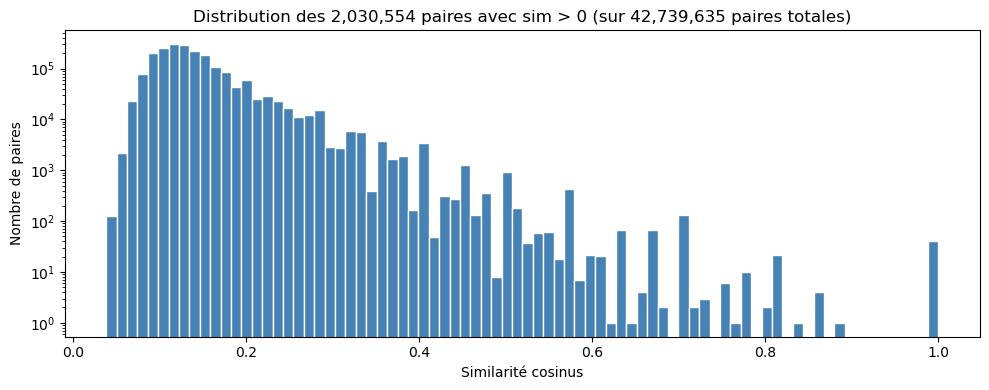

In [10]:
# Distribution des similarités non nulles
import matplotlib.pyplot as plt

print(f'Similarité max   : {data.max():.3f}')
print(f'Similarité moyenne (non nulles) : {data.mean():.4f}')
print(f'Paires avec sim >= 0.5 : {(data >= 0.5).sum():,}')
print(f'Paires avec sim >= 0.3 : {(data >= 0.3).sum():,}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(data, bins=80, color='steelblue', edgecolor='white')
ax.set_xlabel('Similarité cosinus')
ax.set_ylabel('Nombre de paires')
ax.set_title(f'Distribution des {len(data):,} paires avec sim > 0 (sur {n_pairs:,} paires totales)')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

Sur 124,750 paires aléatoires :
  Similarité moyenne : 0.0072
  Paires avec sim > 0 : 6,384 (5.1%)
  Paires avec sim > 0.3 : 111 (0.1%)


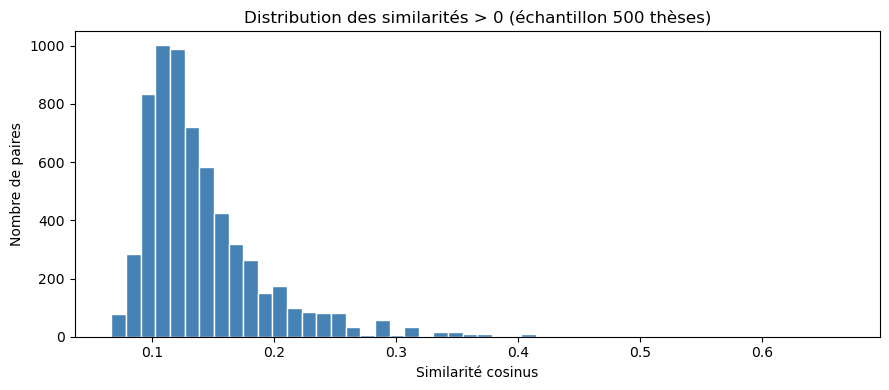

In [26]:
import matplotlib.pyplot as plt

# On calcule les similarités sur un échantillon (toutes les paires = trop lourd)
SAMPLE = 500
idx_sample = np.random.choice(n_docs, SAMPLE, replace=False)
X_sample = X[idx_sample]

sim_matrix = cosine_similarity(X_sample)  # (500 × 500)

# On ne prend que la partie triangulaire supérieure (évite les doublons)
upper = sim_matrix[np.triu_indices(SAMPLE, k=1)]

print(f'Sur {len(upper):,} paires aléatoires :')
print(f'  Similarité moyenne : {upper.mean():.4f}')
print(f'  Paires avec sim > 0 : {(upper > 0).sum():,} ({(upper > 0).mean()*100:.1f}%)')
print(f'  Paires avec sim > 0.3 : {(upper > 0.3).sum():,} ({(upper > 0.3).mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(upper[upper > 0], bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Similarité cosinus')
ax.set_ylabel('Nombre de paires')
ax.set_title(f'Distribution des similarités > 0 (échantillon {SAMPLE} thèses)')
plt.tight_layout()
plt.show()